
### What Problem Do Attention Mechanisms Solve in Neural Machine Translation (NMT)?

Attention mechanisms address a key limitation of early NMT models, which used an **encoder-decoder architecture**. In these models, the encoder had to compress an entire input sentence (like "turn off the lights") into a **single, fixed-length "context vector"**. This single vector was then used by the decoder to generate the output sentence.

The problem was that this fixed-length vector became a **bottleneck for longer sentences (over 30 words), paragraphs, or documents**. The encoder struggled to capture all necessary information, leading to **poor translation quality** for longer inputs.

### What is the Core Idea of an Attention Mechanism?

The main idea of attention is to allow the decoder to **dynamically focus on specific, relevant parts of the input sentence** at each step of generating an output word, rather than relying on a single summary of the entire input.

*   It makes **all intermediate hidden states of the encoder available** to the decoder.
*   For each output word, a **new "context vector" (CI)** is created.
*   This context vector is a **weighted sum** of the encoder's hidden states.
*   The **"weights" (called alignment scores or alphas)** determine how much each encoder hidden state contributes to the current output word, reflecting their importance or similarity.
*   The main challenge then becomes **how to calculate these alignment scores** (alphas).

### What is Bahdanau Attention (Additive Attention)?

Bahdanau Attention is one way to calculate these alignment scores.

*   **What it is**: It's an attention mechanism that uses a **feed-forward neural network, called an "alignment model,"** to compute the alignment scores. This is why it's also known as **Additive Attention**.
*   **How it works**:
    *   The alignment score for an output word (alpha_ij) depends on two things: the **encoder's hidden state (h_j)** and the decoder's **previous hidden state (s_i-1)**. The previous decoder state provides context about what has already been translated.
    *   These two states (s_i-1 and h_j) are fed into the alignment model (feed-forward neural network).
    *   The neural network produces raw alignment scores (e_ij), which are then **normalized using a softmax function** to get the final alpha_ij weights.
    *   The resulting context vector (CI) is then given as an **input to the decoder's LSTM** to help predict the next word.
    *   The parameters (weights) of the feed-forward neural network are **shared across all decoder time steps**.

### What is Luong Attention (Multiplicative Attention)?

Luong Attention was introduced later and offers some improvements over Bahdanau Attention.

*   **What it is**: An attention mechanism that typically uses a **simpler dot product function** to calculate alignment scores, rather than a neural network. This is why it's also known as **Multiplicative Attention**.
*   **How it works**:
    *   The alignment score (alpha_ij) depends on the **encoder's hidden state (h_j)** and the decoder's **current hidden state (s_i)**. Using the current decoder state provides more updated context.
    *   The raw alignment scores (e_ij) are calculated by taking the **dot product between the current decoder hidden state (s_i) and all encoder hidden states (h_j)**. The dot product measures similarity between these vectors.
    *   These scores are then **normalized with a softmax function** to get the final alpha_ij weights.
    *   A key difference is that the calculated context vector (CI) is **concatenated with the decoder's *current* hidden state (s_i) at the *output stage***, before generating the final word.

### What are the Main Differences Between Bahdanau and Luong Attention?

The key distinctions between Bahdanau and Luong attention are:

*   **Alignment Score Calculation**:
    *   **Bahdanau**: Uses a **feed-forward neural network** (alignment model).
    *   **Luong**: Uses a **simpler dot product** operation. This generally means fewer parameters and faster computation.
*   **Decoder State Dependency for Alignment**:
    *   **Bahdanau**: Depends on the decoder's **previous hidden state (s_i-1)**.
    *   **Luong**: Depends on the decoder's **current hidden state (s_i)**. Using the current state provides more updated information, leading to better performance.
*   **Context Vector Usage**:
    *   **Bahdanau**: The context vector (CI) is fed as an **input to the decoder's LSTM**.
    *   **Luong**: The context vector (CI) is **concatenated with the decoder's hidden state at the output layer**, not as an input to the LSTM.
*   **Terminology**:
    *   **Bahdanau**: Often called **Additive Attention**.
    *   **Luong**: Often called **Multiplicative Attention**.

### What are the Benefits of Using Attention Mechanisms?

Attention mechanisms provide significant benefits for NMT:

*   **Improved Translation Quality**: They lead to a **significant boost in translation quality**, with models showing gains of up to 5.0 BLEU points over non-attentional systems.
*   **Better Handling of Long Sentences**: Attention models are **more effective in translating long sentences**, where traditional encoder-decoder models struggled. The quality does not degrade as sentence length increases.
*   **Dynamic Focus**: They allow the model to **selectively focus on relevant parts of the source sentence** for each target word, rather than trying to compress all information into one fixed vector.
*   **Better Alignments**: Attention mechanisms learn **linguistically plausible (soft-)alignments** between source and target words, which helps in correctly translating complex phrases or names.
*   **Robustness**: They make NMT systems more **robust** and able to handle varying sentence lengths effectively.

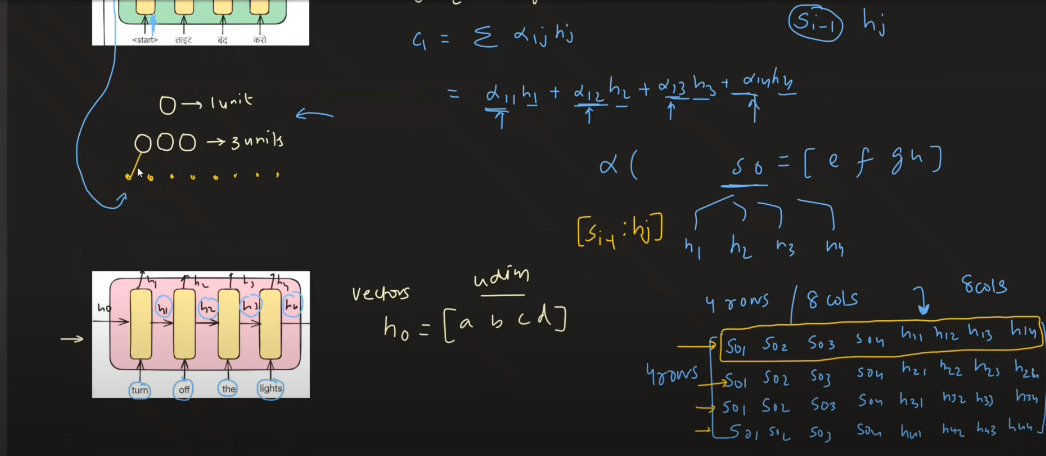

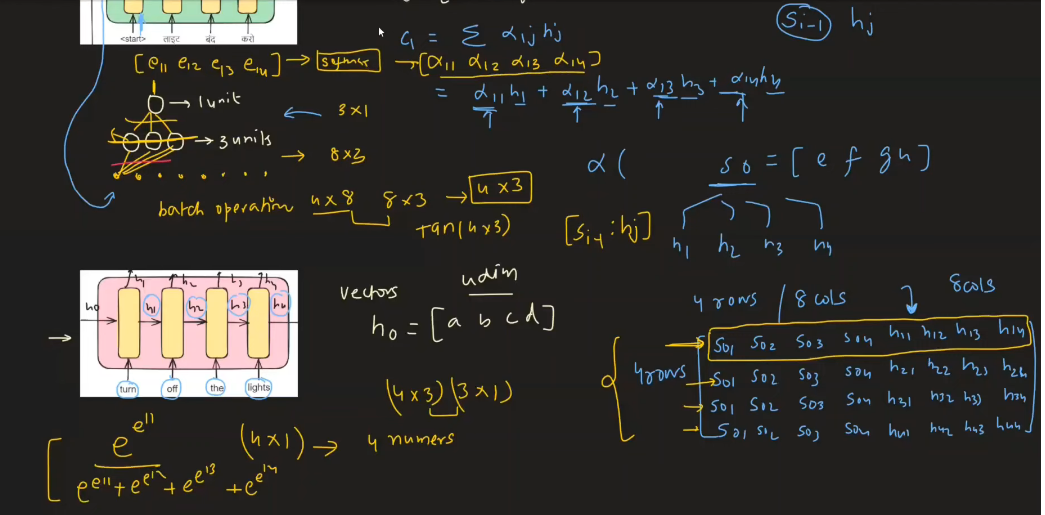

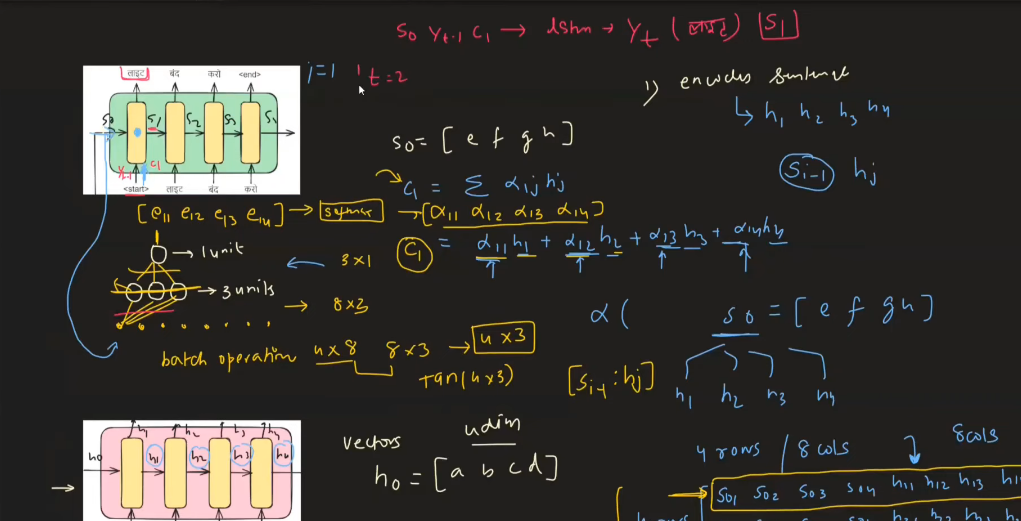

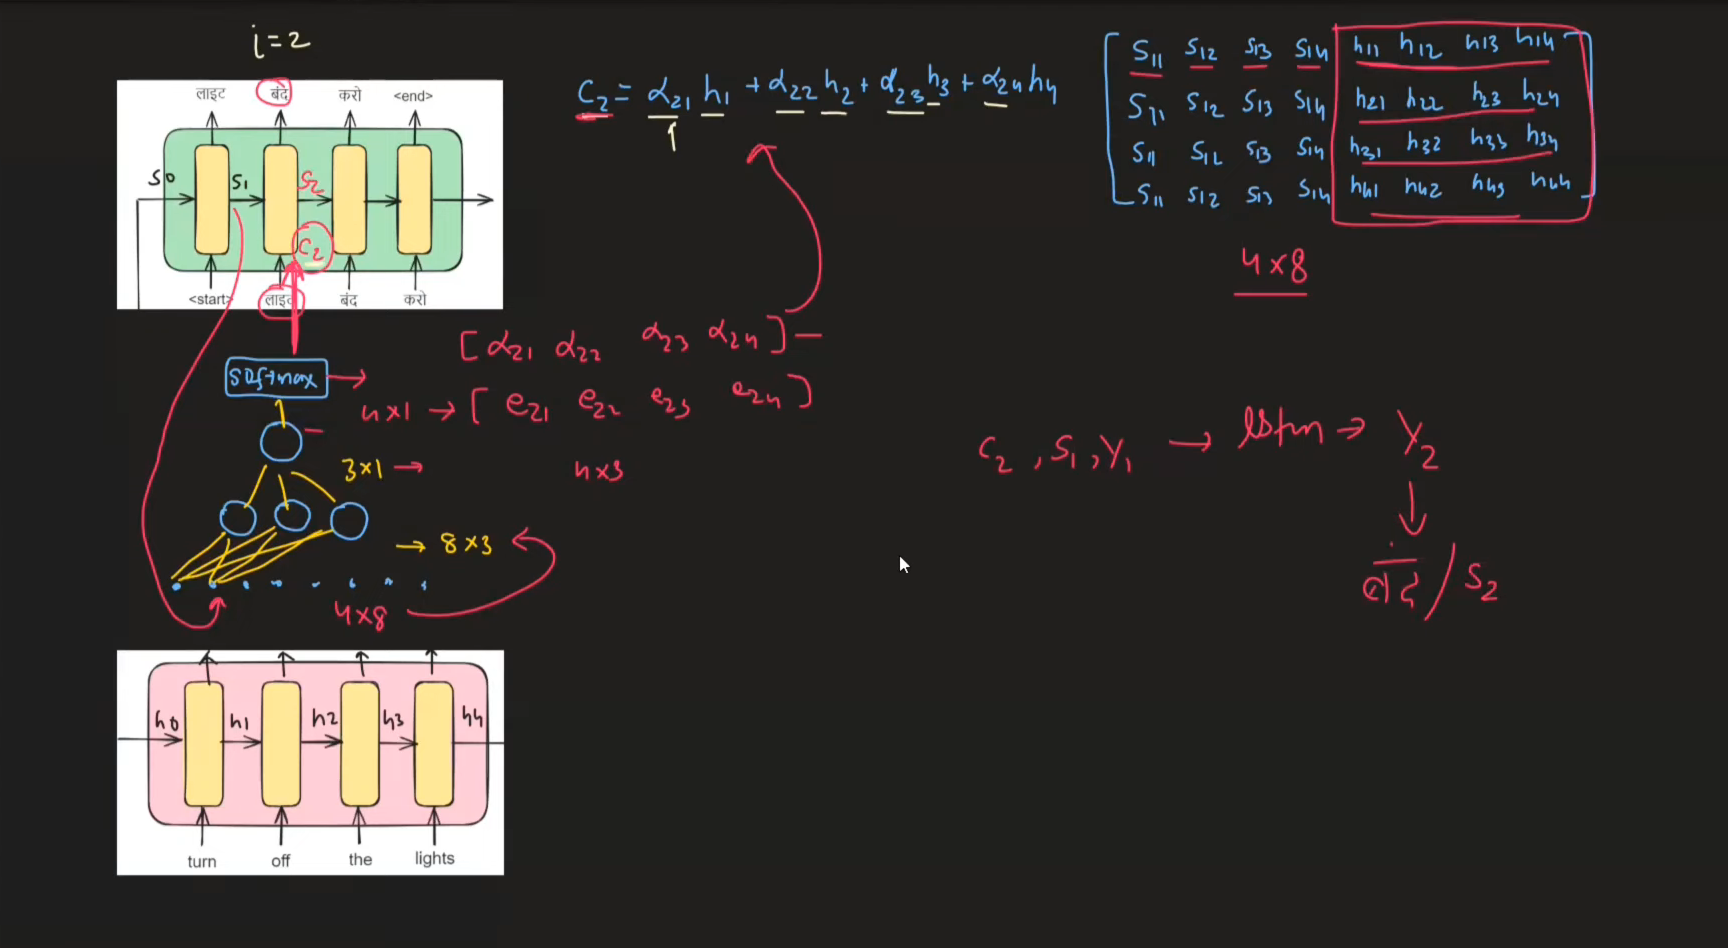

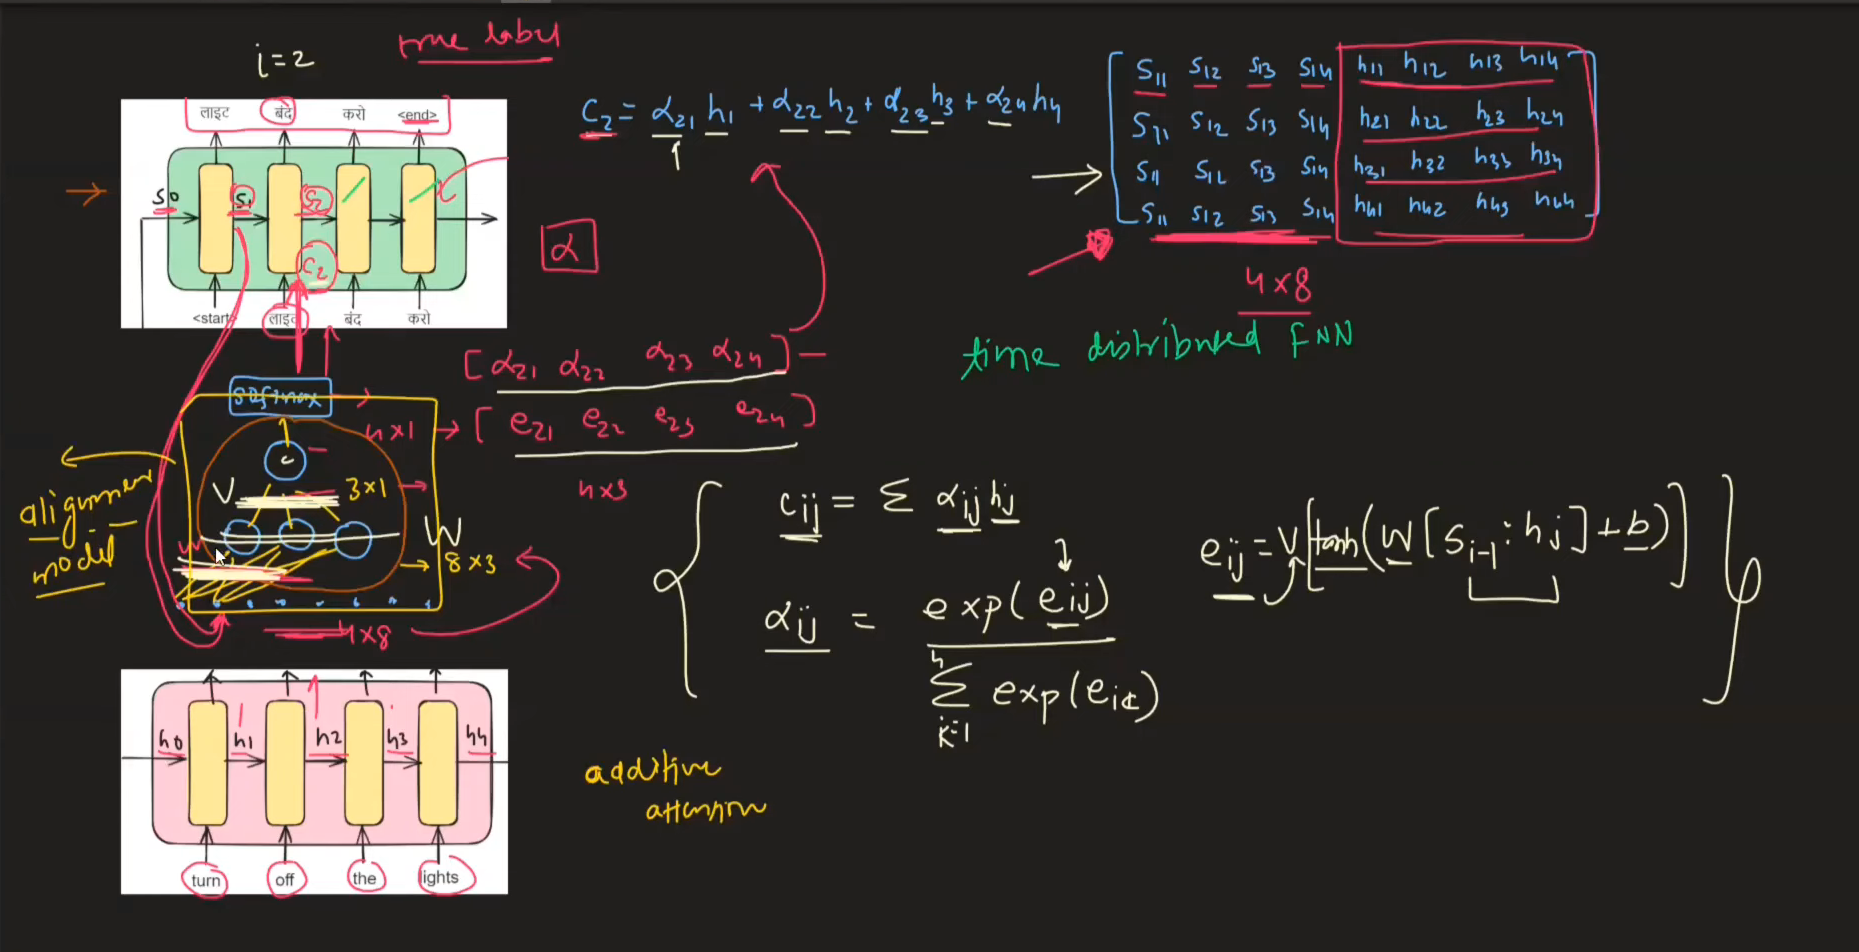

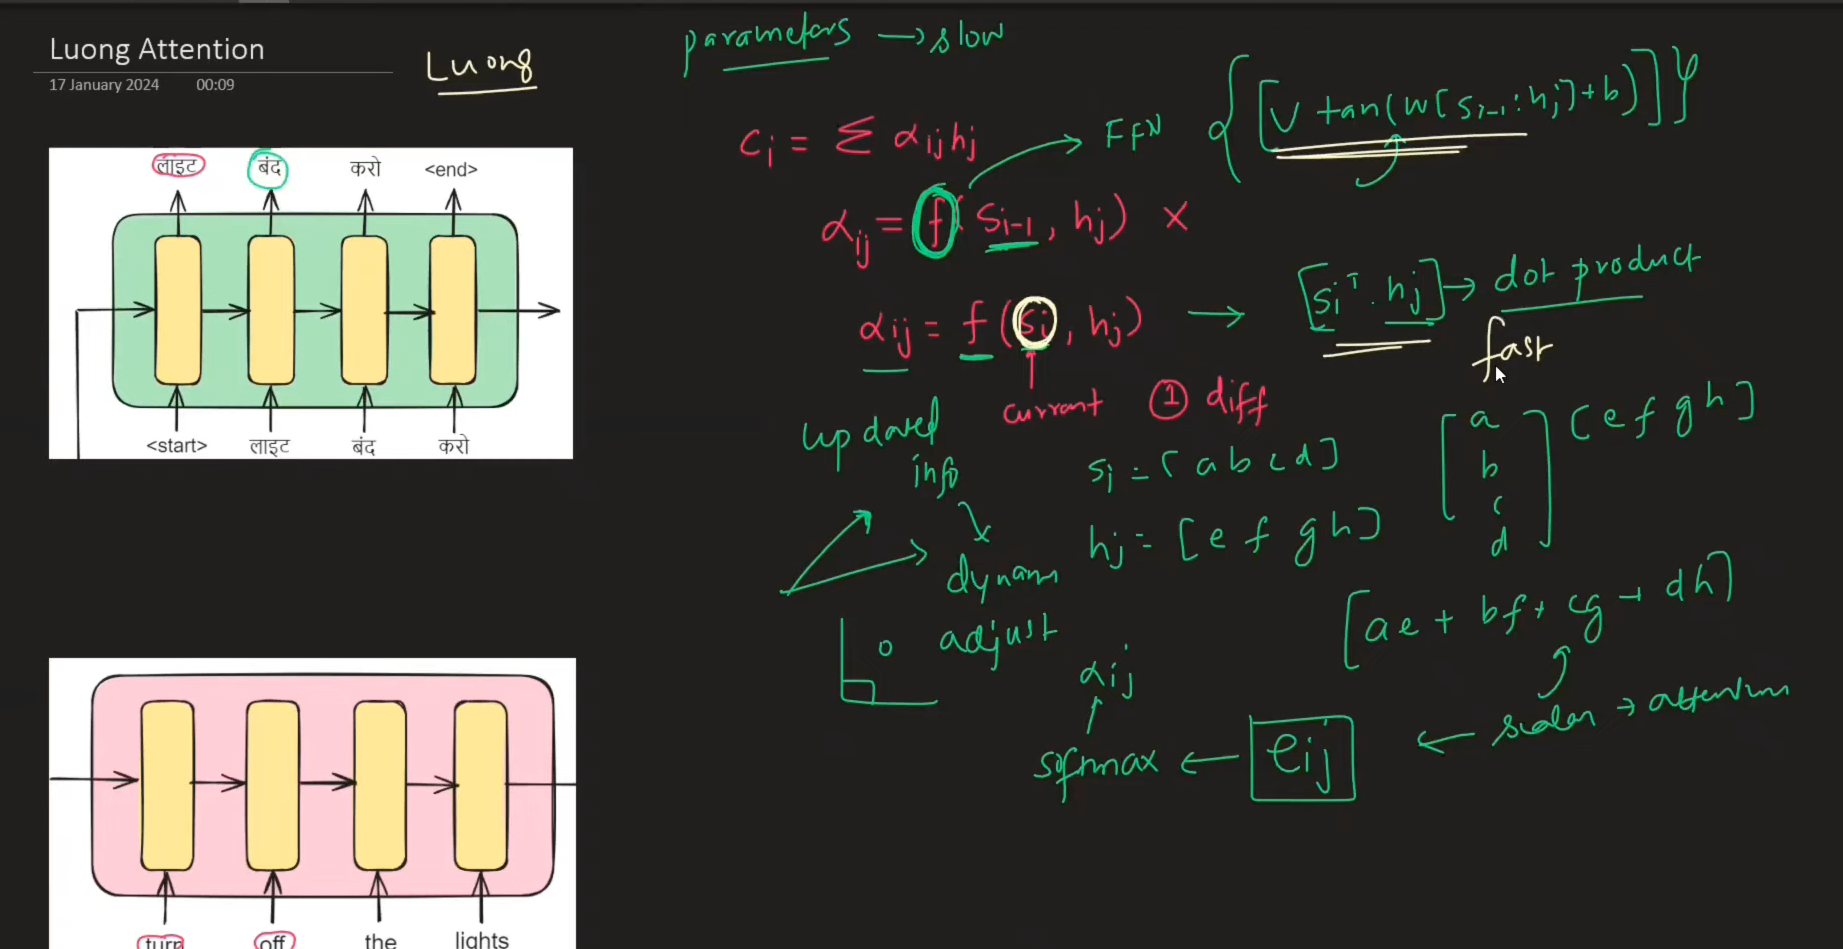

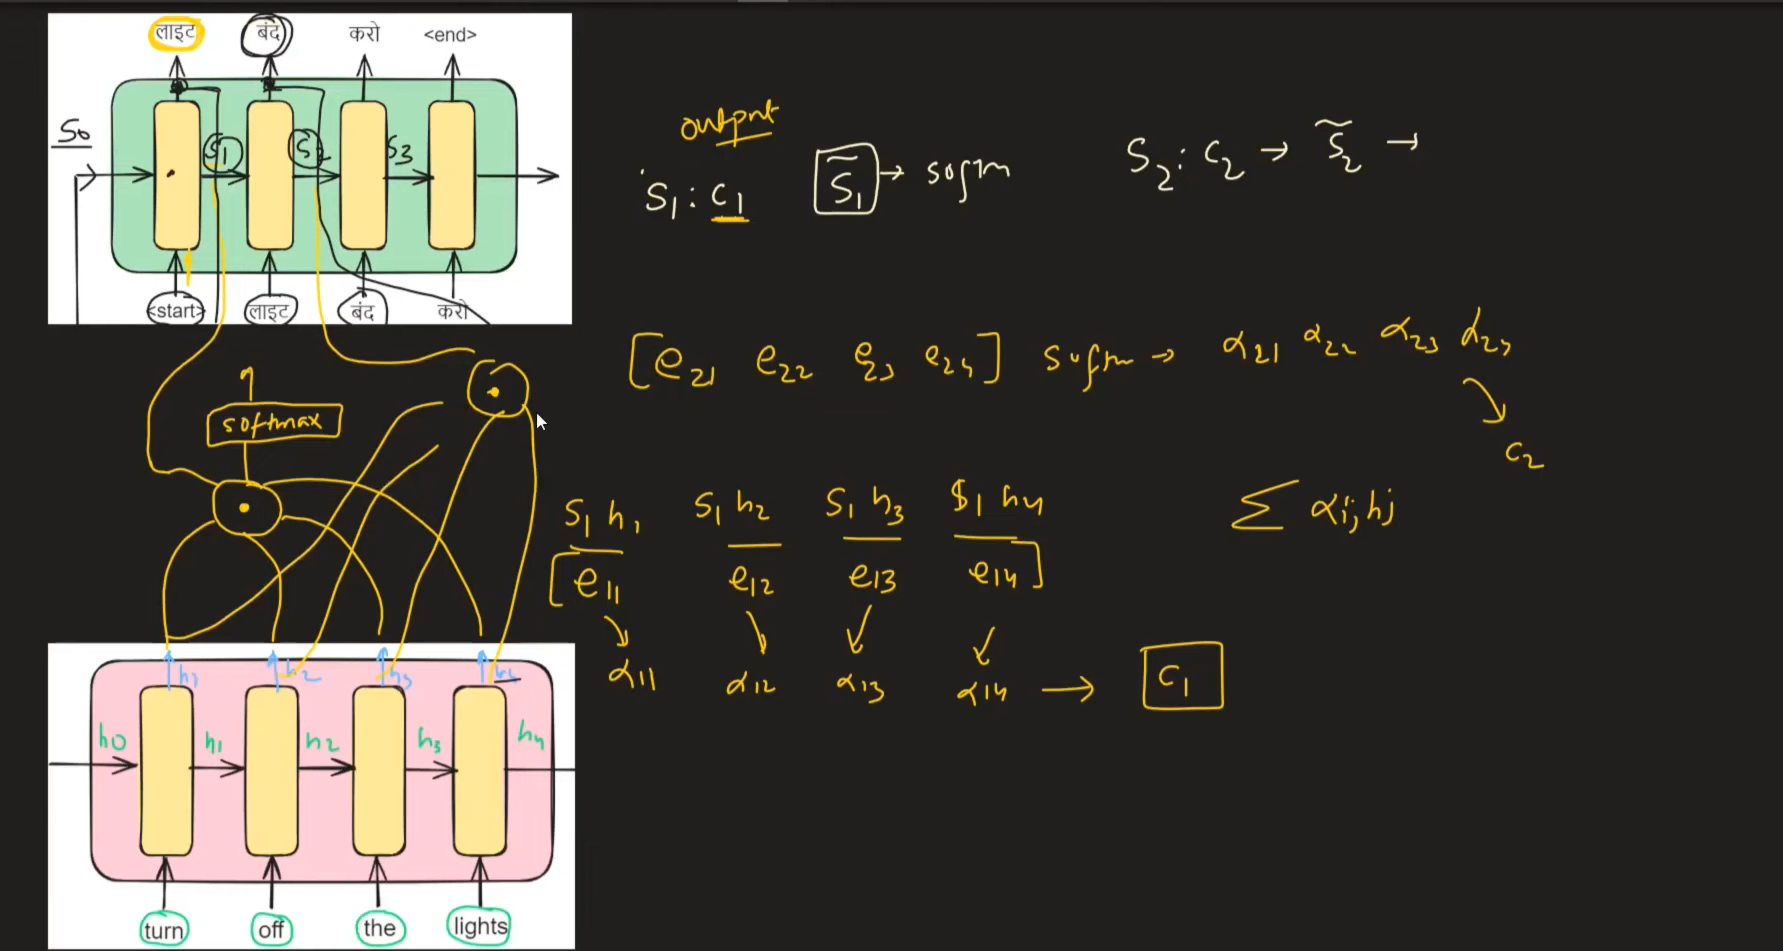



### The Problem Addressed by Attention Mechanisms

Initially, Neural Machine Translation (NMT) problems, like translating "turn off the lights" to "लाइट बंद करो," were attempted using **encoder-decoder architectures**.
*   **Encoder's Role**: The encoder processes the input sentence word by word (e.g., "turn," "off," "the," "lights"). Its job is to create a **context vector**, which is a numerical representation or summary of the input sentence.
*   **Decoder's Role**: This single context vector is then passed to the decoder, which attempts to generate the output sentence word by word (e.g., "light," "बंद," "करो").

**The Bottleneck**: This traditional approach faced a significant problem with **longer sentences (more than 30 words), paragraphs, or documents**. The encoder struggled to compress all the necessary information into a single, fixed-size context vector. As a result, the decoder often produced **poor quality translations** for longer inputs.

### The Core Concept of Attention Mechanism

To overcome this bottleneck, the **Attention Mechanism** was introduced.
*   **Dynamic Relevance**: Instead of a single context vector, attention suggests that when the decoder is generating a specific output word (e.g., "light"), it only needs certain **specific words or a subset of words** from the input sentence, not the entire sentence. For example, to print "light," it might only need "lights" from the input.
*   **Access to Encoder States**: The attention mechanism ensures that **all intermediate hidden states (h1, h2, h3, h4) from the encoder are available** at every time step of the decoder.
*   **Context Vector Calculation (CI)**: At each decoder time step, a new context vector (CI) is created. This CI is a **weighted sum** of the encoder's hidden states.
    *   The weights, known as **alignment scores (alphas)**, determine how much each encoder hidden state contributes to the current output word.
    *   These alphas essentially represent **word-to-word similarity scores** or importance.
*   **The Main Challenge**: The primary challenge in implementing attention is **how to calculate these alignment scores (alphas)**. Bahdanau and Luong attention offer two different methods for this.

---

### Bahdanau Attention (Additive Attention)

**Bahdanau Attention** is one method for calculating the alignment scores, also known as **Additive Attention**.

*   **What it is**: An attention mechanism that uses a **feed-forward neural network (called an alignment model)** to calculate the alignment scores.
*   **Why it was developed**: It was one of the early methods to address the challenge of dynamically calculating the importance of encoder hidden states for each decoder output, improving translation quality for longer sentences.
*   **When it works**: During decoding in NMT, at each time step, to determine how much each encoder hidden state (h_j) contributes to the current output word.
*   **How it works**:
    *   **Dependencies**: The alignment score for a given word (alpha_ij) depends on two things: the **encoder's hidden state (h_j)** and the **decoder's *previous* hidden state (s_i-1)**. The previous decoder state provides context about what has already been translated.
    *   **Calculation of Scores (e_ij)**:
        1.  The **previous decoder hidden state (s_i-1)** and the **current encoder hidden state (h_j)** are **concatenated**.
        2.  This concatenated vector is then fed as input to a **feed-forward neural network** (alignment model). This network typically has one hidden layer.
        3.  The neural network approximates the complex mathematical function that determines the alignment, producing raw alignment scores (e_ij).
    *   **Normalization (Softmax)**: A **softmax function** is applied to these raw e_ij scores to normalize them. This ensures they are positive and sum up to one, resulting in the final **alpha_ij weights**.
    *   **Context Vector (CI) Use**: The calculated context vector (CI) is then provided as an **input to the decoder's LSTM** along with the previous output word and the decoder's previous hidden state to predict the next word.
    *   **Parameter Sharing**: The weights of the feed-forward neural network are shared across all decoder time steps; it's a **time-distributed fully connected neural network**.

---

### Luong Attention (Multiplicative Attention)

**Luong Attention** was developed after Bahdanau Attention and includes several improvements. It is also known as **Multiplicative Attention**.

*   **What it is**: An improved attention mechanism that uses a **simpler function, typically a dot product**, to calculate alignment scores, rather than a neural network.
*   **Why it was developed**: To **improve performance** (by using the current decoder hidden state for more updated information) and to **increase speed and reduce parameters** (by replacing the neural network with a simpler dot product for alignment score calculation).
*   **When it works**: During decoding in NMT, at each time step, to calculate how relevant each encoder hidden state (h_j) is to the decoder's *current* output.
*   **How it works**:
    *   **Dependencies**: The alignment score (alpha_ij) depends on two things: the **encoder's hidden state (h_j)** and the **decoder's *current* hidden state (s_i)**. Using the current decoder state provides more updated context for translation.
    *   **Calculation of Scores (e_ij)**:
        1.  The decoder first calculates its **current hidden state (s_i)** based on its previous state and input.
        2.  This **s_i is then dot-producted with all encoder hidden states (h_j)** to get the raw alignment scores (e_ij). The dot product is chosen because it effectively measures similarity between vectors: higher dot product for similar vectors, lower for dissimilar ones.
    *   **Normalization (Softmax)**: A **softmax function** is applied to these e_ij values to normalize them, resulting in the final **alpha_ij weights**.
    *   **Context Vector (CI) Use**: This is another key difference from Bahdanau. The calculated context vector (CI) is **concatenated with the decoder's *current* hidden state (s_i) at the *output stage***. This concatenated vector then passes through another feed-forward network and softmax layer to produce the final output word.

### Key Improvements of Luong Attention over Bahdanau Attention:
*   **Alignment Score Calculation**: Luong uses a simpler **dot product** instead of a neural network, leading to fewer parameters and faster computation.
*   **Decoder State Dependency**: Luong uses the **current decoder hidden state (s_i)**, providing more updated information, which has been experimentally shown to improve performance.
*   **Context Vector Placement**: The context vector (CI) is **concatenated at the output of the decoder LSTM** rather than fed as an input, changing the flow of information.

Understanding both Bahdanau and Luong attention provides a strong foundation for comprehending the concept of **Self-Attention** in Transformer architectures.

The key differences between Bahdanau Attention (also known as Additive Attention) and Luong Attention (also known as Multiplicative Attention) lie in their methods of calculating alignment scores, their dependencies on decoder states, and how the context vector is integrated into the decoding process.

Here are the main distinctions:

*   **Alignment Score Calculation**:
    *   **Bahdanau Attention**: Uses a **feed-forward neural network** (referred to as an "alignment model") to compute the raw alignment scores (e_ij). This involves concatenating the decoder's previous hidden state with each encoder hidden state and feeding this into the neural network.
    *   **Luong Attention**: Typically uses a **simpler dot product function** between the decoder's hidden state and each encoder hidden state to calculate the raw alignment scores (e_ij). This usually results in fewer parameters and faster computation compared to Bahdanau's method. Luong also explored other functions like "general" (a learned matrix multiplication) and "concat".

*   **Decoder State Dependency for Alignment**:
    *   **Bahdanau Attention**: The alignment score for an output word depends on the decoder's **previous hidden state (s_i-1)** and the encoder's hidden state (h_j). The previous decoder state provides context about what has already been translated.
    *   **Luong Attention**: The alignment score depends on the decoder's **current hidden state (s_i)** and the encoder's hidden state (h_j). Using the current state provides more updated information, which was experimentally shown to lead to better performance.

*   **Context Vector Usage (Integration into Decoder)**:
    *   **Bahdanau Attention**: The calculated context vector (c_i) is fed as an **input to the decoder's LSTM** to help predict the next word. The context vector is used in building subsequent hidden states, which can also achieve a "coverage" effect.
    *   **Luong Attention**: The context vector (c_i) is **concatenated with the decoder's *current* hidden state (s_i) at the *output layer*** (before the final softmax layer that generates the word), rather than as an input to the LSTM itself. This is also referred to as an "input-feeding approach" in the Luong paper, where attentional vectors are fed as inputs to the next time steps to inform about past alignment decisions.

*   **Architectural Complexity and Speed**:
    *   **Bahdanau Attention**: Involves a neural network for alignment, adding more parameters and potentially making training slower, especially for long sentences. Bahdanau et al. utilized a **bidirectional RNN** for the encoder to generate annotations (h_j) by concatenating forward and backward hidden states, capturing information from both preceding and following words.
    *   **Luong Attention**: Uses a simpler dot product, leading to fewer parameters and generally faster computation.

*   **Generalization and Performance**:
    *   **Bahdanau Attention (RNNsearch)**: Demonstrated significant improvements in translation quality over basic encoder-decoder models, especially for **long sentences**, where translation quality did not degrade with increasing sentence length. It was also shown to find **linguistically plausible soft-alignments**.
    *   **Luong Attention**: Also showed significant gains (up to 5.0 BLEU points) over non-attentional systems and achieved **new state-of-the-art results** on WMT translation tasks. Luong et al. noted that their global attention approach is "similar in spirit" to Bahdanau's but is **architecturally simpler**. The local attention model with predictive alignments (local-p) proved to be even better than global attention in their experiments.

*   **Encoder/Decoder Details (as noted by Luong et al. comparing their "Global Attention" to Bahdanau et al.)**:
    *   **Bahdanau et al. (2015)**: Used the concatenation of forward and backward source hidden states from a bi-directional encoder and target hidden states from their non-stacking unidirectional decoder. Their computation path involves building from the **previous hidden state (h_t-1)** to derive the context vector, which then influences the current hidden state (h_t), passing through a deep-output and maxout layer before making predictions.
    *   **Luong et al. (2015)**: Simply used hidden states at the **top LSTM layers** in both the encoder and decoder. Their computation path is simpler, going from the **current target hidden state (h_t)** to the alignment vector (a_t) to the context vector (c_t) to the attentional hidden state (h̃_t), and then making a prediction. They also explored various alignment functions, whereas Bahdanau et al. primarily used one (the concat product).